# C2.4 Basic Gyroscope Dynamics
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.4.1 What Is a Gyroscope?

Have you ever spun a bicycle wheel while holding it by the axle and tried to tilt it? If so, you’ve felt the strange resistance to change in direction—that's the magic of **gyroscopic stability**.

A **gyroscope** is a rigid body (typically a disk or wheel) that spins rapidly around an internal axis. The body is often mounted so it can pivot freely, allowing the spin axis to change orientation in response to applied torques.

What makes gyroscopes fascinating is their **counterintuitive response** to external forces. Instead of tipping in the direction of the torque (like a book pushed over on a table), the gyroscope's spin axis **precesses**—it moves *perpendicularly* to the direction you pushed. This behavior is a direct consequence of **angular momentum** and how it resists changes in direction, not just in size. It’s one of the most beautiful examples of rotation in three dimensions.

### Gyroscopes Are Everywhere

Gyroscopes aren’t just cool toys or science demos—they’re essential in the modern world. Here are just a few places where gyroscopes play a crucial role:

- **Spacecraft Attitude Control**: When there's no up or down, how do you know which way your satellite is facing? Gyroscopes help spacecraft stay properly oriented without relying on external forces. They form the heart of **inertial navigation systems** used by NASA, SpaceX, and more.
  
- **Smartphones & Game Controllers**: Every time your phone rotates the screen or your controller detects a twist, it’s using tiny **MEMS gyroscopes**—microelectromechanical devices that detect angular motion.

- **Drones & Airplanes**: Flight stabilization in quadcopters and airplanes relies on gyroscopes. They help maintain balance during flight, especially when conditions are turbulent or during acrobatic maneuvers.

- **Motorcycles & Bicycles**: The stability of a moving bike is partly due to gyroscopic effects in the spinning wheels.

- **Fidget Spinners & Toys**: Even the humble fidget spinner demonstrates a bit of gyroscopic behavior. Try pushing on it while it spins and feel how it reacts differently than when it's at rest.

### Some Illustrative Videos

Here are some short and fascinating videos that *show* gyroscopic behavior in a way words can't:

- [The Mystery of the Spinning Top – Veritasium](https://www.youtube.com/watch?v=tLMpdBjA2SU)
- [Gyroscopic Precession - Veritasium](https://www.youtube.com/watch?v=ty9QSiVC2g0)

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.4.2 Angular Momentum and Rotational Stability

For a rotating rigid body, the **angular momentum** is given by:

$$
\vec{L} = \mathbf{I} \cdot \vec{\omega}
$$

In the case of a symmetric gyroscope rotating about a fixed axis, the inertia tensor reduces to a scalar $ I $ about that axis:

$$
\vec{L} = I \vec{\omega}
$$

This vector points along the axis of rotation and remains **constant in the absence of external torque**. This conservation is what gives the gyroscope its **stability**: it resists reorientation unless a torque acts on it.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.4.3 External Torque and Precession

Suppose we now apply a torque $ \vec{\tau} $ to the gyroscope—like gravity pulling down on the center of mass when the axis is tilted. Newton’s second law for rotation tells us:

$$
\vec{\tau} = \frac{d\vec{L}}{dt}
$$

If $ \vec{\tau} \perp \vec{L} $, then the magnitude of $ \vec{L} $ doesn’t change, but its **direction** does. The tip of the angular momentum vector $ \vec{L} $ moves along a circle over time, which corresponds to **precession** of the spin axis.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.4.4 Why $ \frac{d\vec{L}}{dt} = \vec{\Omega} \times \vec{L} $

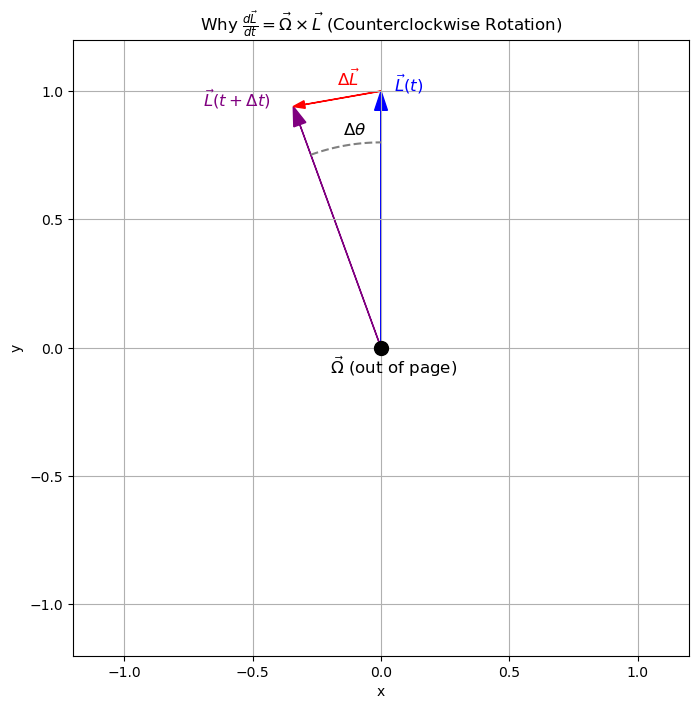

In [2]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Set up figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r"Why $\frac{d\vec{L}}{dt} = \vec{\Omega} \times \vec{L}$ (Counterclockwise Rotation)")

# Define original L and its rotated version
L_mag = 1.0
theta = np.deg2rad(20)  # small counterclockwise rotation
L = np.array([0, L_mag])
L_rotated = np.array([-L_mag * np.sin(theta), L_mag * np.cos(theta)])  # CCW rotation

# Draw vectors
ax.arrow(0, 0, L[0], L[1], head_width=0.05, color='blue', length_includes_head=True)
ax.text(L[0]+0.05, L[1], r'$\vec{L}(t)$', fontsize=12, color='blue')

ax.arrow(0, 0, L_rotated[0], L_rotated[1], head_width=0.05, color='purple', length_includes_head=True)
ax.text(L_rotated[0]-0.35, L_rotated[1], r'$\vec{L}(t + \Delta t)$', fontsize=12, color='purple')

# Delta L vector
delta_L = L_rotated - L
ax.arrow(L[0], L[1], delta_L[0], delta_L[1], head_width=0.03, color='red', length_includes_head=True)
ax.text(L[0] + 0.5*delta_L[0], L[1] + 0.5*delta_L[1] + 0.05, r'$\Delta \vec{L}$', fontsize=12, color='red')

# Represent Omega as out of the plane with a dot
ax.plot(0, 0, marker='o', markersize=10, color='black')  # Dot = out of plane
ax.text(-0.2, -0.1, r'$\vec{\Omega}$ (out of page)', fontsize=12)
ax.text(-0.15, 0.83, r'$\Delta\theta$', fontsize=12)

# Arc to show rotation
arc = np.linspace(-theta, 0, 100)
r = L_mag * 0.8
ax.plot(r * np.sin(arc), r * np.cos(arc), linestyle='--', color='gray')

# Grid and show
plt.grid(True)
plt.show()


Let’s suppose that $ \vec{L} $ rotates slowly around some axis with angular velocity $ \vec{\Omega} $. Since only its **direction** changes, we can model this using infinitesimal rotation.

Considering the Figure above, we have that 

$$
\Delta\vec{L} \sim (\Delta\theta~\hat{z})\times\vec{L}
$$

Diving by $\Delta t$ and taking the limit, we have that **any** vector $ \vec{A} $ rotating at angular velocity $ \vec{\Omega} $, its rate of change of that vector is:

$$
\frac{d\vec{A}}{dt} = \vec{\Omega} \times \vec{A}
$$

Why is this true?

- The change $ d\vec{A} $ is perpendicular to both $ \vec{A} $ and $ \vec{\Omega} $.
- Its magnitude is $ |\vec{A}| \cdot \Omega \cdot dt $ (arc length).
- The direction follows from the right-hand rule.

Apply this to angular momentum:

$$
\frac{d\vec{L}}{dt} = \vec{\Omega} \times \vec{L}
$$

This expression describes **how $ \vec{L} $ rotates in space**. It doesn’t mean that $ \vec{\Omega} $ causes $ \vec{L} $—rather, it tells us the instantaneous rate and direction of change if $ \vec{L} $ is rotating with angular velocity $ \vec{\Omega} $.

In the presence of torque, we also know:

$$
\vec{\tau} = \frac{d\vec{L}}{dt}
$$

So when precession occurs, we combine these two results:

$$
\vec{\tau} = \vec{\Omega} \times \vec{L}
$$

From this, the precession rate is:

$$
\Omega = \frac{\tau}{L}
\quad \text{(when } \vec{\tau} \perp \vec{L} \text{)}
$$

This equation captures the essence of gyroscopic behavior.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.4.5 Calculating the Precession Rate

Let’s put it all together in a basic model:

- A spinning disk of mass $ M $, radius $ R $, angular speed $ \omega $,
- Pivoted at a point a distance $ r $ from the center of mass.

Then:

- Moment of inertia:  

  $$
  I = \frac{1}{2} M R^2
  $$
  
- Angular momentum: 

  $$
  L = I \omega
  $$
  
- Torque due to gravity: 

  $$
  \tau = M g r
  $$
  
- Precession rate:  

  $$
  \Omega = \frac{M g r}{I \omega}
  $$

This tells us that **faster spinning** leads to **slower precession**—a crucial stability feature in real-world gyroscopes.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.4.6 Learning Outcomes

We should now be able to:

- **Explain** the role of angular momentum in stabilizing the orientation of a spinning gyroscope.
- **Describe** gyroscopic precession as a result of torque-induced change in angular momentum direction.
- **Use** the vector identity $ \vec{\tau} = \vec{\Omega} \times \vec{L} $ to understand the geometry of precession.
- **Derive** the precession rate $ \Omega = \dfrac{M g r}{I \omega} $ from first principles.
- **Apply** these results to analyze real-world systems such as spinning tops, drone stabilizers, and satellite gyros.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.4.6 Up Next

In the next phase, we will go into more depth and

- Derive precession for asymmetric rigid bodies (non-principal axis spin).
- Explore **nutation**: the oscillatory wobble that occurs in addition to precession.
- Use numerical simulation to visualize gyroscope motion over time.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">